### K-Means Clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from sklearn.datasets import make_blobs

In [4]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [5]:
x


array([[ 3.24923391,  8.36610196],
       [ 3.9686217 ,  9.97961347],
       [ 3.70044376,  7.51112939],
       ...,
       [ 2.34227034, -6.8117956 ],
       [ 2.75907108,  6.54178862],
       [ 3.49243831,  9.08990644]], shape=(1000, 2))

In [6]:
y

array([0, 2, 0, 1, 2, 2, 2, 0, 2, 1, 1, 0, 0, 0, 2, 1, 0, 1, 2, 1, 2, 0,
       2, 0, 0, 2, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 2, 2,
       2, 1, 0, 1, 1, 2, 2, 2, 1, 1, 2, 0, 0, 2, 0, 1, 2, 0, 1, 0, 1, 0,
       1, 2, 2, 1, 0, 2, 0, 1, 0, 0, 2, 1, 2, 0, 2, 2, 1, 1, 2, 0, 0, 0,
       2, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 1, 0, 1, 0, 2, 2, 2, 0, 2, 2, 0,
       1, 2, 2, 0, 2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 2, 2, 0, 1, 2,
       0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 2, 2, 1,
       2, 2, 2, 0, 2, 0, 2, 1, 1, 0, 1, 0, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2,
       1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 1, 0,
       2, 0, 1, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 2, 0, 1, 0, 1, 2, 1, 1, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 2, 1,
       0, 2, 0, 1, 2, 0, 2, 0, 0, 2, 1, 1, 2, 0, 1, 2, 1, 1, 2, 2, 2, 0,
       1, 0, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2,

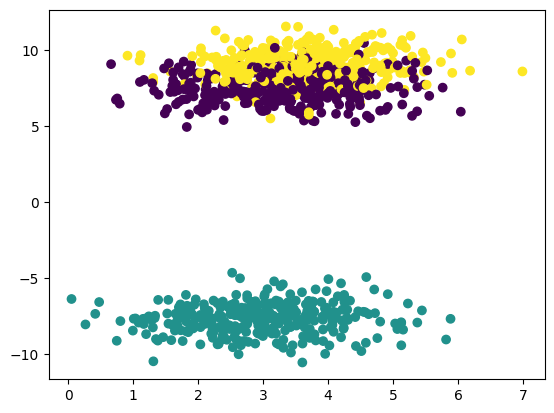

In [9]:
plt.scatter(x[:,0],x[:,1],c=y)

In [11]:
### Sandardisation -- Features scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [16]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [18]:
from sklearn.cluster import KMeans 

In [19]:
### Elbow method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)    

In [20]:
wcss

[1340.000000000001,
 642.2481518745218,
 370.9932694386505,
 250.2152868127708,
 164.74939010400308,
 133.11613791489057,
 105.44624450307441,
 89.86835299257383,
 74.14439439146302,
 63.36531527186365]

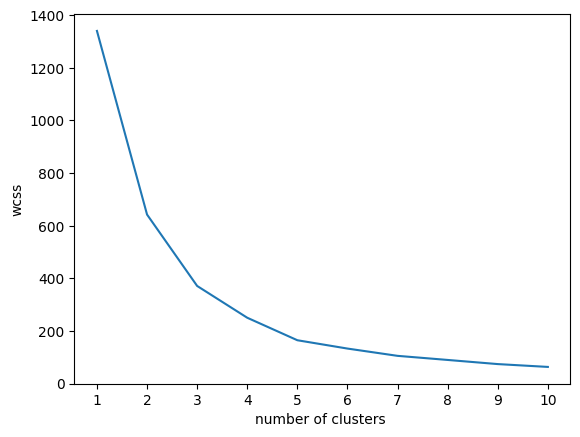

In [21]:
## plot thw elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters ")
plt.ylabel("wcss")
plt.show()

In [35]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [36]:
kmeans.fit_predict(x_train_scaled)

array([1, 0, 1, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 0,
       1, 0, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 0, 0, 1, 1,
       2, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1,
       2, 1, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 2, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 2, 2, 2, 2, 0, 2, 0, 2, 1, 1, 1, 2,
       0, 2, 0, 2, 2, 0, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       1, 2, 1, 0, 1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 2,
       1, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 1, 1, 0, 1, 1, 2,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 1, 2, 1, 2,
       1, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 0, 0, 2, 2, 1, 2, 0, 1, 0, 1, 2,
       1, 1, 1, 0, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 0, 0, 2, 0, 1, 2, 1, 2,
       2, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 2, 2, 0, 0, 1, 0, 1, 0, 2, 0,
       0, 2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 2, 0, 0, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 0,

In [37]:
y_pred=kmeans.predict(x_test_scaled)

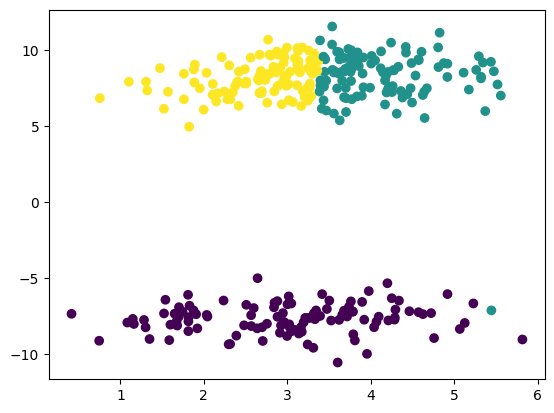

In [38]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [39]:
##3 validating the k value
## kneelocator
## silhoutee scoring


In [42]:
#kneelocator
!pip install kneed

In [43]:
from kneed import KneeLocator


In [44]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [45]:
kl.elbow

np.int64(3)

In [46]:
## silhoute scoring
from sklearn.metrics import silhouette_score

In [47]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [48]:
silhouette_coefficients

[0.5560215442337991,
 0.5125779731578874,
 0.5102510856047855,
 0.5077636602371407,
 0.4918484983146582,
 0.46153451635745907,
 0.44994735765909477,
 0.43483679528935765,
 0.43074895523957213]

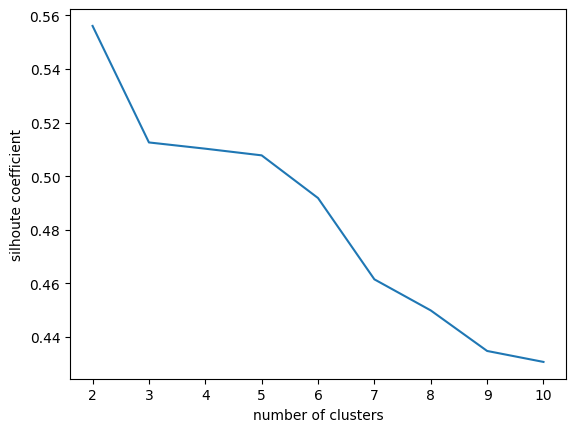

In [49]:
### plotting silhoutee score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhoute coefficient")
plt.show()